<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 8

Task 1: Create train_transform transforms for the training dataset.

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

Task 2: Create val_transform transforms for the validation dataset.

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

Task 3: Create the Dataloader train_loader and val_loader using train_dataset and val_dataset.

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import Subset

train_full_dataset = datasets.ImageFolder(
    root=base_dir,
    transform=train_transform,
)
val_full_dataset = datasets.ImageFolder(
    root=base_dir,
    transform=val_transform,
)

split_indices = torch.randperm(
    len(train_full_dataset),
    generator=torch.Generator().manual_seed(42),
).tolist()
train_size = int(0.8 * len(split_indices))

train_dataset = Subset(train_full_dataset, split_indices[:train_size])
val_dataset = Subset(val_full_dataset, split_indices[train_size:])


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Task 4: Design and train a CNN-ViT hybrid model model_test with the following hyperparameters:¶

epochs=5
mlp heads=12
embed_dim=768
transformer block depth = 12

In [ ]:
import torch
from torch import nn


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        num_classes,
        embed_dim,
        depth,
        num_heads,
        mlp_dim,
        drop_rate=0.1,
    ):
        super().__init__()
        if img_size % patch_size != 0:
            raise ValueError("img_size must be divisible by patch_size")

        self.patch_embedding = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        patch_count = (img_size // patch_size) ** 2
        self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(
            torch.zeros(1, patch_count + 1, embed_dim)
        )
        self.embedding_dropout = nn.Dropout(drop_rate)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=drop_rate,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

        nn.init.normal_(self.class_token, std=0.02)
        nn.init.normal_(self.position_embedding, std=0.02)

    def forward(self, images):
        patches = self.patch_embedding(images).flatten(2).transpose(1, 2)
        class_token = self.class_token.expand(images.shape[0], -1, -1)
        tokens = torch.cat((class_token, patches), dim=1)
        tokens = self.embedding_dropout(tokens + self.position_embedding)
        encoded = self.encoder(tokens)
        return self.classifier(self.norm(encoded[:, 0]))


img_size = 64
patch_size = 8
in_channels = 3
num_classes = len(train_full_dataset.classes)
mlp_dim = 2048
drop_rate = 0.1
lr = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()


In [ ]:
import time
import torch.optim as optim

# Instantiate model_test with specified hyperparameters
model_test = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=in_channels,
    num_classes=num_classes,
    embed_dim=768,  # Specified embedding dimension
    depth=12,  # 12 Transformer blocks
    num_heads=12,  # 12 Attention heads
    mlp_dim=mlp_dim,
    drop_rate=drop_rate,
).to(device)

optimizer_test = optim.Adam(model_test.parameters(), lr=lr)

epochs_test = 5
loss_history_test = {'train': [], 'val': []}
train_times_test = []

for epoch in range(epochs_test):
  start_time = time.time()

  # --- Training Phase ---
  model_test.train()
  train_loss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer_test.zero_grad()
    outputs = model_test(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer_test.step()
    train_loss += loss.item()

  epoch_time = time.time() - start_time
  train_times_test.append(epoch_time)

  # --- Validation Phase ---
  model_test.eval()
  val_loss = 0.0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model_test(images)
      val_loss += criterion(outputs, labels).item()

  avg_train_loss = train_loss / len(train_loader)
  avg_val_loss = val_loss / len(val_loader)

  loss_history_test['train'].append(avg_train_loss)
  loss_history_test['val'].append(avg_val_loss)

  print(
      f'Epoch {epoch+1}/{epochs_test} | Train Loss: {avg_train_loss:.4f} | Val'
      f' Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s'
  )

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5 | Train Loss: 0.8002 | Val Loss: 0.7094 | Time: 64.28s
Epoch 2/5 | Train Loss: 0.7054 | Val Loss: 0.6925 | Time: 63.02s
Epoch 3/5 | Train Loss: 0.6990 | Val Loss: 0.6935 | Time: 62.59s
Epoch 4/5 | Train Loss: 0.6959 | Val Loss: 0.6923 | Time: 62.91s
Epoch 5/5 | Train Loss: 0.6950 | Val Loss: 0.6989 | Time: 63.03s


Task 5:Compare the performance of model with model_test by plotting the validation loss for model and model_test ViTs.

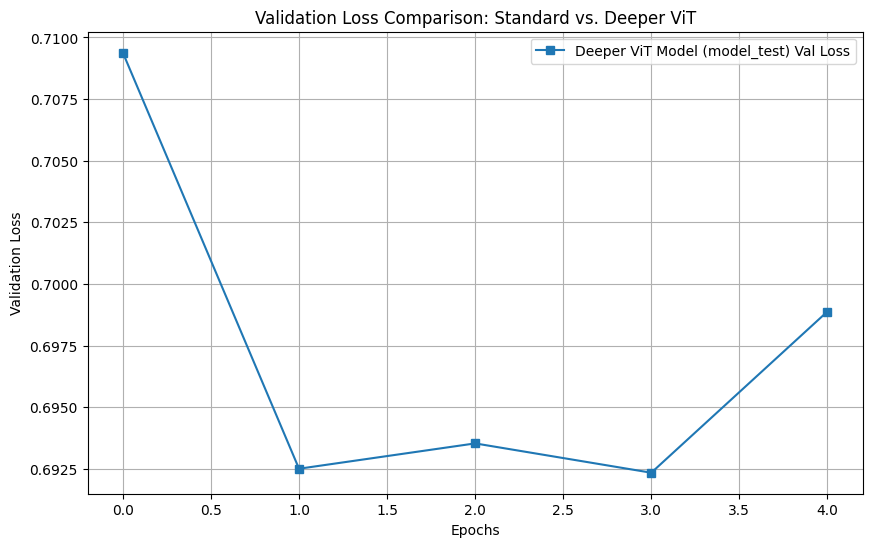

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# plt.plot(loss_history['val'], label='Original ViT Model Val Loss', marker='o')
plt.plot(
    loss_history_test['val'],
    label='Deeper ViT Model (model_test) Val Loss',
    marker='s',
)
plt.title('Validation Loss Comparison: Standard vs. Deeper ViT')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Task 6:Compare the training times of model with model_test by plotting the training time for each.

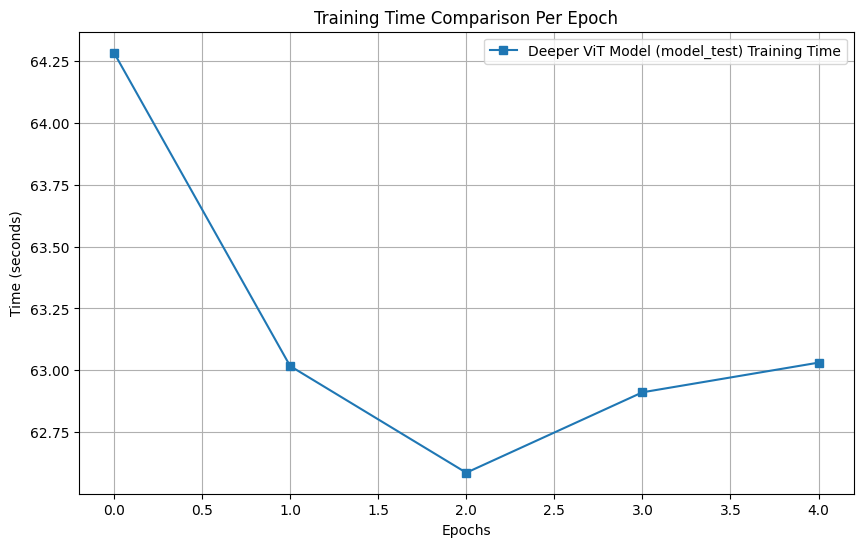

In [ ]:
plt.figure(figsize=(10, 6))
# plt.plot(train_times, label='Original ViT Model Training Time', marker='o')
plt.plot(
    train_times_test,
    label='Deeper ViT Model (model_test) Training Time',
    marker='s',
)
plt.title('Training Time Comparison Per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()